# Tips for Running This Notebook (Read Before Running)
For running this notebook, most cells can be run one after the other besides when trainning the two different models and preprocessing the data for the models.

In order to cut down on the amount of time needed to run this notebook, you can skip running the bayesian optimizer since I have already found the best fitting models for both the Genre Tags and Categories. Each model is encompassed in its own function within its own cell that can be run individually. If you want to run the bayesian optimizer be prepared for a hour and twenty minute wait for the nerual network to find the best version.

When preprocessing the data make sure you use the version of the data for the right model. There is two versions (just like when trainning the model), one version that uses the genre tags as the X value and one version that uses the categories as the X value.

In [ ]:
import os
import sys
import shutil

!pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# NOTE: This cell is primarily for installing kagglehub and setting up
# the environment for dataset loading via kagglehub. The previous
# manual data source loading logic is removed as it's no longer needed.

# <p style= "background-color:#428da6;font-family:Georgia;padding: 6px;color:#FFFFFF;font-size:110%;text-align:center;border-radius:30px 60px;overflow:hidden;">Importing Main Dependencies</p>

In [1]:
import pandas as pd # for data manipulation
import numpy as np # for linear algebra
import matplotlib.pyplot as plt # for plotting

#Loading Dataset

In [2]:
#import kagglehub
#from kagglehub import KaggleDatasetAdapter

# This code is for directly importing from kaggle.
# Instead I am using the hard copy from my google drive.
# ------------------------------------------------------

# Set the path to the file you'd like to load
#clean_file = "games_march2025_cleaned.csv"

# Load the latest version
#df = kagglehub.dataset_load(
#  KaggleDatasetAdapter.PANDAS,
#  "artermiloff/steam-games-dataset",
#  clean_file
#)

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/CSS581/FinalProject/mod_games_cleaned.csv")

# Displaying our data
df.head()

Mounted at /content/drive


,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,total_pos_reviews,years_since_release,tags_clean
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473,7424327,13,"('FPS', 'Shooter', 'Multiplayer', 'Competitive..."
1,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366,1986601,12,"('Free to Play', 'MOBA', 'Multiplayer', 'Strat..."
2,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517,1569333,10,"('Open World', 'Action', 'Multiplayer', 'Crime..."
3,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720,1483166,8,"('Survival', 'Shooter', 'Battle Royale', 'Mult..."
4,105600,Terraria,2011-05-16,0,9.99,2,"Dig, Fight, Explore, Build: The very world is ...","Dig, Fight, Explore, Build: The very world is ...","Dig, fight, explore, build! Nothing is impossi...",NaN,...,0,30516,"{'Open World Survival Craft': 16365, 'Sandbox'...",97,1102434,96,8860,1069360,14,"('Open World Survival Craft', 'Sandbox', 'Surv..."


# Make a copy of the dataframe

In [3]:
new_df = df
new_df.head(10)

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,total_pos_reviews,years_since_release,tags_clean
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473,7424327,13,"('FPS', 'Shooter', 'Multiplayer', 'Competitive..."
1,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366,1986601,12,"('Free to Play', 'MOBA', 'Multiplayer', 'Strat..."
2,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517,1569333,10,"('Open World', 'Action', 'Multiplayer', 'Crime..."
3,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720,1483166,8,"('Survival', 'Shooter', 'Battle Royale', 'Mult..."
4,105600,Terraria,2011-05-16,0,9.99,2,"Dig, Fight, Explore, Build: The very world is ...","Dig, Fight, Explore, Build: The very world is ...","Dig, fight, explore, build! Nothing is impossi...",NaN,...,0,30516,"{'Open World Survival Craft': 16365, 'Sandbox'...",97,1102434,96,8860,1069360,14,"('Open World Survival Craft', 'Sandbox', 'Surv..."
5,440,Team Fortress 2,2007-10-10,0,0.00,1,'The most fun you can have online' - PC Gamer ...,'The most fun you can have online' - PC Gamer ...,Nine distinct classes provide a broad range of...,NaN,...,0,50817,"{'Free to Play': 62868, 'Hero Shooter': 61020,...",89,1146642,93,8172,1020511,18,"('Free to Play', 'Hero Shooter', 'Multiplayer'..."
6,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608,981136,10,"('FPS', 'PvP', 'e-sports', 'Multiplayer', 'Tac..."
7,4000,Garry's Mod,2006-11-29,0,5.99,0,Garry's Mod is a physics sandbox. There aren't...,Garry's Mod is a physics sandbox. There aren't...,Garry's Mod is a physics sandbox. There aren't...,“It brings back the silly glee of unbridled ex...,...,40,32384,"{'Sandbox': 18706, 'Moddable': 14479, 'Multipl...",96,985010,96,8277,945609,19,"('Sandbox', 'Moddable', 'Multiplayer', 'Physic..."
8,252490,Rust,2018-02-08,0,39.99,4,The only aim in Rust is to survive. Everything...,The only aim in Rust is to survive. Everything...,The only aim in Rust is to survive. Everything...,"“Rust is one of the cruelest games on Steam, a...",...,0,200902,"{'Survival': 18592, 'Crafting': 11822, 'Multip...",87,993856,87,14960,864654,8,"('Survival', 'Crafting', 'Multiplayer', 'Open ..."
9,2358720,Black Myth: Wukong,2024-08-19,13,59.99,2,Digital Deluxe Edition The Black Myth: Wukong ...,Black Myth: Wukong is an action RPG rooted in ...,Black Myth: Wukong is an action RPG rooted in ...,NaN,...,0,35990,"{'Mythology': 9421, 'Action RPG': 7720, 'Actio...",96,825621,94,6139,792596,1,"('Mythology', 'Action RPG', 'Action', 'Souls-l..."


# Sorting Data By Most Positive Reviews

In [ ]:
new_df['total_pos_reviews'] = new_df['num_reviews_total'] * (new_df['pct_pos_total'] * 0.01)
new_df['total_pos_reviews'] = new_df['total_pos_reviews'].astype(int)

new_df = new_df.sort_values(by="total_pos_reviews", ascending=False)
new_df.head(10)

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,total_pos_reviews,years_since_release,tags_clean
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473,7424327,13,"('FPS', 'Shooter', 'Multiplayer', 'Competitive..."
1,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366,1986601,12,"('Free to Play', 'MOBA', 'Multiplayer', 'Strat..."
2,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517,1569333,10,"('Open World', 'Action', 'Multiplayer', 'Crime..."
3,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720,1483166,8,"('Survival', 'Shooter', 'Battle Royale', 'Mult..."
4,105600,Terraria,2011-05-16,0,9.99,2,"Dig, Fight, Explore, Build: The very world is ...","Dig, Fight, Explore, Build: The very world is ...","Dig, fight, explore, build! Nothing is impossi...",NaN,...,0,30516,"{'Open World Survival Craft': 16365, 'Sandbox'...",97,1102434,96,8860,1069360,14,"('Open World Survival Craft', 'Sandbox', 'Surv..."
5,440,Team Fortress 2,2007-10-10,0,0.00,1,'The most fun you can have online' - PC Gamer ...,'The most fun you can have online' - PC Gamer ...,Nine distinct classes provide a broad range of...,NaN,...,0,50817,"{'Free to Play': 62868, 'Hero Shooter': 61020,...",89,1146642,93,8172,1020511,18,"('Free to Play', 'Hero Shooter', 'Multiplayer'..."
6,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608,981136,10,"('FPS', 'PvP', 'e-sports', 'Multiplayer', 'Tac..."
7,4000,Garry's Mod,2006-11-29,0,5.99,0,Garry's Mod is a physics sandbox. There aren't...,Garry's Mod is a physics sandbox. There aren't...,Garry's Mod is a physics sandbox. There aren't...,“It brings back the silly glee of unbridled ex...,...,40,32384,"{'Sandbox': 18706, 'Moddable': 14479, 'Multipl...",96,985010,96,8277,945609,19,"('Sandbox', 'Moddable', 'Multiplayer', 'Physic..."
8,252490,Rust,2018-02-08,0,39.99,4,The only aim in Rust is to survive. Everything...,The only aim in Rust is to survive. Everything...,The only aim in Rust is to survive. Everything...,"“Rust is one of the cruelest games on Steam, a...",...,0,200902,"{'Survival': 18592, 'Crafting': 11822, 'Multip...",87,993856,87,14960,864654,8,"('Survival', 'Crafting', 'Multiplayer', 'Open ..."
9,2358720,Black Myth: Wukong,2024-08-19,13,59.99,2,Digital Deluxe Edition The Black Myth: Wukong ...,Black Myth: Wukong is an action RPG rooted in ...,Black Myth: Wukong is an action RPG rooted in ...,NaN,...,0,35990,"{'Mythology': 9421, 'Action RPG': 7720, 'Actio...",96,825621,94,6139,792596,1,"('Mythology', 'Action RPG', 'Action', 'Souls-l..."


# Adding the Total Age Feature
By subtracting the current year (2026) to the year of the released game we get the amount of years a game has been released.

In [ ]:
new_df['release_date'] = pd.to_datetime(new_df['release_date'])

# Calculate years since release
today = pd.Timestamp.today()
new_df['years_since_release'] = (today - new_df['release_date']).dt.days / 365.25

# Optional: make it an integer
new_df['years_since_release'] = new_df['years_since_release'].astype(int)

new_df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,total_pos_reviews,years_since_release,tags_clean
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473,7424327.54,13,"('FPS', 'Shooter', 'Multiplayer', 'Competitive..."
1,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366,1986601.95,12,"('Free to Play', 'MOBA', 'Multiplayer', 'Strat..."
2,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517,1569333.84,10,"('Open World', 'Action', 'Multiplayer', 'Crime..."
3,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720,1483166.78,8,"('Survival', 'Shooter', 'Battle Royale', 'Mult..."
4,105600,Terraria,2011-05-16,0,9.99,2,"Dig, Fight, Explore, Build: The very world is ...","Dig, Fight, Explore, Build: The very world is ...","Dig, fight, explore, build! Nothing is impossi...",NaN,...,0,30516,"{'Open World Survival Craft': 16365, 'Sandbox'...",97,1102434,96,8860,1069360.98,14,"('Open World Survival Craft', 'Sandbox', 'Surv..."


# Cleaning the Tags Feature

Removing the dictionary format (key, value) so that only just the genre category is left for when we encode the data.

In [ ]:
import ast

def clean_tags(x):
    if isinstance(x, str):
        x = ast.literal_eval(x)

    if isinstance(x, dict):
        return list(x.keys())

    if isinstance(x, list):
        return x

    return []

new_df['tags_clean'] = new_df['tags'].apply(clean_tags)
new_df['tags_clean'] = new_df["tags_clean"].apply(tuple)

new_df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,total_pos_reviews,years_since_release,tags_clean
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473,7424327.54,13,"(FPS, Shooter, Multiplayer, Competitive, Actio..."
1,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366,1986601.95,12,"(Free to Play, MOBA, Multiplayer, Strategy, e-..."
2,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517,1569333.84,10,"(Open World, Action, Multiplayer, Crime, Autom..."
3,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720,1483166.78,8,"(Survival, Shooter, Battle Royale, Multiplayer..."
4,105600,Terraria,2011-05-16,0,9.99,2,"Dig, Fight, Explore, Build: The very world is ...","Dig, Fight, Explore, Build: The very world is ...","Dig, fight, explore, build! Nothing is impossi...",NaN,...,0,30516,"{'Open World Survival Craft': 16365, 'Sandbox'...",97,1102434,96,8860,1069360.98,14,"(Open World Survival Craft, Sandbox, Survival,..."


# (Optional After Modification) Save the changed data frame to a modified csv file:

In [ ]:
# Optional save to modified dataframe
# new_df.to_csv('/content/drive/MyDrive/CSS581/FinalProject/mod_games_cleaned.csv', index=False)

# Exploratory Data Analysis


# List all unique genre tags

In [27]:
import ast

# Convert strings to tuples if necessary
ff = new_df['tags_clean'].apply(ast.literal_eval)
nef = ff.explode()

print("Number of different genres:", nef.nunique())
print("List of different genres:", nef.unique())

Number of different genres: 452
List of different genres: ['FPS' 'Shooter' 'Multiplayer' 'Competitive' 'Action' 'Team-Based'
 'e-sports' 'Tactical' 'First-Person' 'PvP' 'Online Co-Op' 'Co-op'
 'Strategy' 'Military' 'War' 'Difficult' 'Trading' 'Realistic'
 'Fast-Paced' 'Moddable' 'Free to Play' 'MOBA' 'RTS' 'RPG' 'Tower Defense'
 'Fantasy' 'Character Customization' 'Replay Value' 'Action RPG'
 'Simulation' 'Open World' 'Crime' 'Automobile Sim' 'Third Person'
 'Mature' 'Adventure' 'Singleplayer' 'Third-Person Shooter' 'Racing'
 'Sandbox' 'Atmospheric' 'Funny' 'Great Soundtrack' 'Comedy' 'Survival'
 'Battle Royale' 'Early Access' 'Stealth' 'Open World Survival Craft' '2D'
 'Pixel Graphics' 'Crafting' 'Building' 'Exploration' 'Indie' 'Platformer'
 'Hero Shooter' 'Class-Based' 'Cartoony' 'Robots' 'Cartoon' 'Destruction'
 '3D' 'Physics' 'Casual' 'Nudity' 'Post-apocalyptic' 'Mythology'
 'Souls-like' 'Combat' 'Story Rich' 'Action-Adventure' 'Drama'
 'Dark Fantasy' 'Hack and Slash' 'Music' 'Vio

# List all unique categories

In [28]:
# Convert strings to tuples if necessary
ff = new_df['categories'].apply(ast.literal_eval)
nef = ff.explode()

print("Number of different genres:", nef.nunique())
print("List of different genres:", nef.unique())

Number of different genres: 40
List of different genres: ['Multi-player' 'Cross-Platform Multiplayer' 'Steam Trading Cards'
 'Steam Workshop' 'In-App Purchases' 'Valve Anti-Cheat enabled' 'Stats'
 'Remote Play on Phone' 'Remote Play on Tablet' 'Remote Play on TV'
 'Steam Timeline' 'Co-op' 'SteamVR Collectibles' 'Single-player' 'PvP'
 'Online PvP' 'Online Co-op' 'Steam Achievements'
 'Full controller support' 'Steam Cloud' 'Family Sharing'
 'Captions available' 'Partial Controller Support' 'Includes level editor'
 'Commentary available' 'LAN PvP' 'LAN Co-op' 'Includes Source SDK' 'MMO'
 'Shared/Split Screen Co-op' 'Shared/Split Screen' 'Remote Play Together'
 'Tracked Controller Support' 'VR Supported' 'HDR available'
 'Shared/Split Screen PvP' 'VR Support' 'Steam Leaderboards'
 'Steam Turn Notifications' 'VR Only' nan]


# Ranges for Numerical Features

In [15]:
print("Price range:", new_df['price'].min(), "-" ,new_df['price'].max())
print("Price total positive reviews:", new_df['total_pos_reviews'].min(), "-" ,new_df['total_pos_reviews'].max())
print("Price years since release:", new_df['years_since_release'].min(), "-" ,new_df['years_since_release'].max())

Price range: 0.0 - 999.98
Price total positive reviews: 0 - 7424327
Price years since release: 0 - 28


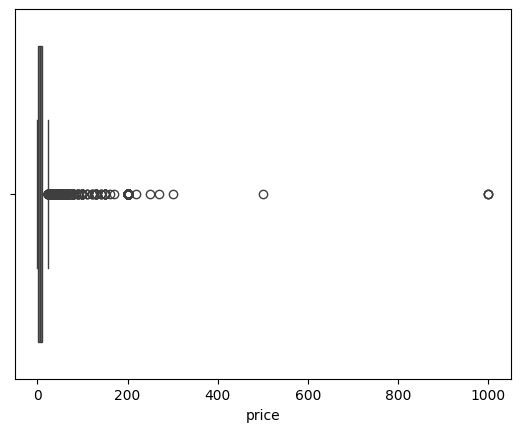

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=new_df, x='price')

plt.show()

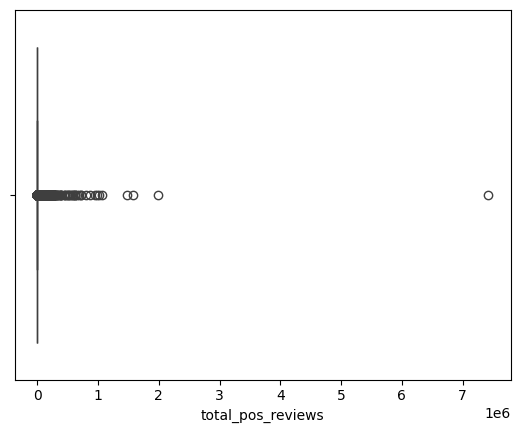

In [21]:
sns.boxplot(data=new_df, x='total_pos_reviews')

plt.show()

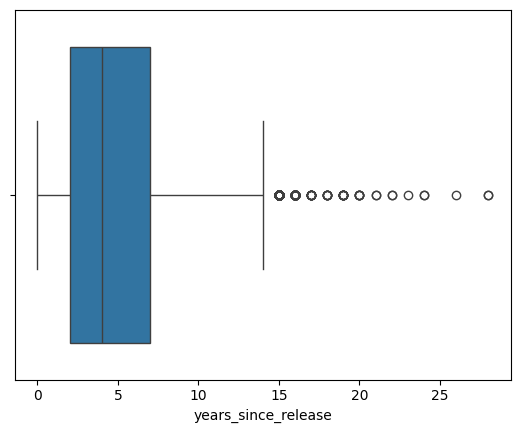

In [22]:
sns.boxplot(data=new_df, x='years_since_release')

plt.show()

# Feature  Selecting & Data Cleaning


Next I isolate the features that will be important for deciding how tags and categories might be chosen by the reccommender. The current list of features to be included in the data frame:

*   Name
*   Genre Tags
*   Categories (Game Features)
*   Short Game Description
*   Years Since Release
*   Price
*   Total Positive Reviews

In [ ]:
dataset_features = [
    "name",
    "tags_clean",
    "categories",
    "short_description",
    "years_since_release",
    "price",
    "total_pos_reviews"
]

vf = new_df[dataset_features]
vf.head()

,name,tags_clean,categories,short_description,years_since_release,price,total_pos_reviews
0,Counter-Strike 2,"('FPS', 'Shooter', 'Multiplayer', 'Competitive...","['Multi-player', 'Cross-Platform Multiplayer',...","For over two decades, Counter-Strike has offer...",13,0.00,7424327
1,Dota 2,"('Free to Play', 'MOBA', 'Multiplayer', 'Strat...","['Multi-player', 'Co-op', 'Steam Trading Cards...","Every day, millions of players worldwide enter...",12,0.00,1986601
2,Grand Theft Auto V Legacy,"('Open World', 'Action', 'Multiplayer', 'Crime...","['Single-player', 'Multi-player', 'PvP', 'Onli...",Grand Theft Auto V for PC offers players the o...,10,0.00,1569333
3,PUBG: BATTLEGROUNDS,"('Survival', 'Shooter', 'Battle Royale', 'Mult...","['Multi-player', 'PvP', 'Online PvP', 'Stats',...",Play PUBG: BATTLEGROUNDS for free. Land on str...,8,0.00,1483166
4,Terraria,"('Open World Survival Craft', 'Sandbox', 'Surv...","['Single-player', 'Multi-player', 'PvP', 'Onli...","Dig, fight, explore, build! Nothing is impossi...",14,9.99,1069360


In [ ]:
quarter = int(len(df) * 0.15)
end = len(df)

vf = vf.drop(vf.index[quarter:end])
vf.tail()

,name,tags_clean,categories,short_description,years_since_release,price,total_pos_reviews
13437,Trouble Witches Origin - Episode1 Daughters of...,"('Action', 'Indie', ""Shoot 'Em Up"", 'Anime', '...","['Single-player', 'Steam Achievements', 'Full ...",That witches come back undergone a power-up fu...,9,9.99,180
13438,Cinderella Phenomenon: Evermore,"('Visual Novel', 'Romance', 'Otome', 'Dating S...","['Single-player', 'Steam Achievements', 'Famil...",What happens after Happily Ever After…?,5,9.99,180
13439,Sudoku Jigsaw / 拼图数独,"('Casual', 'Strategy', 'Indie', 'Puzzle', 'Dif...","['Single-player', 'Steam Achievements', 'Steam...","Love Sudoku, but tired of default one? Try this.",7,2.99,180
13440,Gachimuchi Reloaded,"('Indie', 'Violent', 'Adventure', 'Sexual Cont...","['Single-player', 'Steam Achievements', 'Parti...",♂DO♂YOU♂LIKE♂WHAT♂YOU♂SEE﻿?,8,0.99,180
13441,Pixel Puzzles Junior Jigsaw,"('Casual', 'Indie', 'Simulation', 'Strategy', ...","['Single-player', 'Steam Achievements', 'Steam...","Pixel Puzzles Junior, The perfect puzzle game ...",9,0.00,180


In [ ]:
# Printing shape of dataframe
vf.shape

(13442, 7)

In [ ]:
# Checking number of missing values
vf.isna().sum()

,0
name,0
tags_clean,0
categories,0
short_description,26
years_since_release,0
price,0
total_pos_reviews,0


In [ ]:
# Dropping missing values
vf = vf.dropna()

# Checking number of missing values
vf.isna().sum()

,0
name,0
tags_clean,0
categories,0
short_description,0
years_since_release,0
price,0
total_pos_reviews,0


In [ ]:
# Checking the number of identical records
vf.duplicated().sum()

np.int64(4)

In [ ]:
# Printing shape of dataframe
vf.shape

(13416, 7)

In [ ]:
# Checking data types
vf.dtypes

,0
name,object
tags_clean,object
categories,object
short_description,object
years_since_release,int64
price,float64
total_pos_reviews,int64


# Preprocessing The Data
The following steps involve encoding data apart of the data frame before training the model.

# Run if You Are Looking for Genre Tag Reccomendations

In [ ]:

# Splitting data into X and target
X = vf.drop('tags_clean', axis=1)

title = vf['tags_clean']
title.head()

,tags_clean
0,"('FPS', 'Shooter', 'Multiplayer', 'Competitive..."
1,"('Free to Play', 'MOBA', 'Multiplayer', 'Strat..."
2,"('Open World', 'Action', 'Multiplayer', 'Crime..."
3,"('Survival', 'Shooter', 'Battle Royale', 'Mult..."
4,"('Open World Survival Craft', 'Sandbox', 'Surv..."


# Run if You Are Looking For Category Reccomendations

In [ ]:
# Splitting data into X and target
X = vf.drop('categories', axis=1)

title = vf['categories']
title.head()

,categories
0,"['Multi-player', 'Cross-Platform Multiplayer',..."
1,"['Multi-player', 'Co-op', 'Steam Trading Cards..."
2,"['Single-player', 'Multi-player', 'PvP', 'Onli..."
3,"['Multi-player', 'PvP', 'Online PvP', 'Stats',..."
4,"['Single-player', 'Multi-player', 'PvP', 'Onli..."


### Encoding and scaling all features

In [ ]:
styles = {}

X.head(2).style.apply(lambda x: [styles.get(col, '') for col in x.index], axis=1)

,name,tags_clean,short_description,years_since_release,price,total_pos_reviews
0,Counter-Strike 2,"('FPS', 'Shooter', 'Multiplayer', 'Competitive', 'Action', 'Team-Based', 'e-sports', 'Tactical', 'First-Person', 'PvP', 'Online Co-Op', 'Co-op', 'Strategy', 'Military', 'War', 'Difficult', 'Trading', 'Realistic', 'Fast-Paced', 'Moddable')","For over two decades, Counter-Strike has offered an elite competitive experience, one shaped by millions of players from across the globe. And now the next chapter in the CS story is about to begin. This is Counter-Strike 2.",13,0.000000,7424327
1,Dota 2,"('Free to Play', 'MOBA', 'Multiplayer', 'Strategy', 'e-sports', 'Team-Based', 'Competitive', 'Action', 'Online Co-Op', 'PvP', 'Difficult', 'Co-op', 'RTS', 'RPG', 'Tower Defense', 'Fantasy', 'Character Customization', 'Replay Value', 'Action RPG', 'Simulation')","Every day, millions of players worldwide enter battle as one of over a hundred Dota heroes. And no matter if it's their 10th hour of play or 1,000th, there's always something new to discover. With regular updates that ensure a constant evolution of gameplay, features, and heroes, Dota 2 has taken on a life of its own.",12,0.000000,1986601


### X Features need different type of preprocessing. Categorical features need to be encoded and numerical need to be scaled. Below are the choosen features what transformations used on each feature.

#### numerical features:
- **year_since_release** (MinMax)
- **price** (MinMax)
- **total_pos_reviews** (MinMax)

#### categorical features:
- **tags_clean** (MultiLabelBinarizer)
- **categories** (MultiLabelBinarizer)
- **short_description** (TF-IDF Vectorizer)

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MultiLabelBinarizer

from sklearn.pipeline import Pipeline

class MultiLabelBinarizerWrapper(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.mlb = MultiLabelBinarizer()

    def fit(self, X, y=None):
        self.mlb.fit(X.squeeze())
        return self

    def transform(self, X):
        return self.mlb.transform(X.squeeze())

tags_pipeline = Pipeline([
    ("mlb", MultiLabelBinarizerWrapper())
])

categories_pipeline = Pipeline([
    ("mlb", MultiLabelBinarizerWrapper())
])

# Code for Preprocessing the Genres Model (Genres Only!)

In [ ]:
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer, FunctionTransformer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.compose import make_column_transformer

# Creating an instance of the preprocessing classes
mms = MinMaxScaler()
mlb = MultiLabelBinarizer()
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

# Log scaling to reduce possible skew of expensive games
vf['total_pos_reviews'] = np.log1p(vf['total_pos_reviews'])

# Creating a make_column_transformer object
preprocessor = make_column_transformer(
    (mms, ['years_since_release']),
    (mms, ['price']),
    (mms, ['total_pos_reviews']),
    #(MultiLabelBinarizerWrapper(), ['tags_clean']),
    (MultiLabelBinarizerWrapper(), ['categories']),
    (vectorizer, 'name'),
    (vectorizer, 'short_description')
)

# Performing the preprocessing operation
X_processed  = preprocessor.fit_transform(X)

X_processed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 744114 stored elements and shape (13416, 10074)>

# Code for Preprocessing the Categories Model (Categories Only!)

In [ ]:
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer, FunctionTransformer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.compose import make_column_transformer

# Creating an instance of the preprocessing classes
mms = MinMaxScaler()
mlb = MultiLabelBinarizer()
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

# Log scaling to reduce possible skew of expensive games
vf['total_pos_reviews'] = np.log1p(vf['total_pos_reviews'])

# Creating a make_column_transformer object
preprocessor = make_column_transformer(
    (mms, ['years_since_release']),
    (mms, ['price']),
    (mms, ['total_pos_reviews']),
    (MultiLabelBinarizerWrapper(), ['tags_clean']),
    #(MultiLabelBinarizerWrapper(), ['categories']),
    (vectorizer, 'name'),
    (vectorizer, 'short_description')
)

# Performing the preprocessing operation
X_processed  = preprocessor.fit_transform(X)

X_processed

In [ ]:
# Converting sparse matrix to normal array
X_processed = X_processed.toarray()

X_processed

array([[0.44444444, 0.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       [0.40740741, 0.        , 0.26756219, ..., 0.        , 0.        ,
        0.        ],
       [0.33333333, 0.        , 0.21135802, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.22222222, 0.03322591, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.25925926, 0.01100122, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.2962963 , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

# Building the Encoder

In [ ]:
# Installing keras-tuner
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.0 MB/s eta 0:00:00


# Setting up network for Bayesian Optimization: (Optional if Bayesian Optimization has been run for given predictive feature)

In [ ]:
from tensorflow.keras.losses import cosine_similarity
from keras.layers import Input, Dense
from keras.models import Model
import tensorflow as tf

# Metric to test the accuracy of reconstructed features
def cosine_similarity_metric(y_true, y_pred):
    return tf.reduce_mean(cosine_similarity(y_true, y_pred))

# Function for building diffrent models using keras_tuner
def build_model(hp):
    input_shape = X_processed.shape[1]
    input_layer = Input(shape=(input_shape,))

    outer_units = hp.Int('outer_units', min_value=128, max_value=256, step=64)
    inner_units = hp.Int('inner_units', min_value=32, max_value=128, step=32)
    bottleneck = hp.Int('bottleneck', min_value=8, max_value=32, step=8)

    hidden_layer1 = Dense(units=outer_units, activation='relu')(input_layer)
    hidden_layer2 = Dense(units=inner_units, activation='relu')(hidden_layer1)
    hidden_layer3 = Dense(units=bottleneck, activation='relu')(hidden_layer2)
    hidden_layer4 = Dense(units=inner_units, activation='relu')(hidden_layer3)
    hidden_layer5 = Dense(units=outer_units, activation='relu')(hidden_layer4)

    output_layer = Dense(units=input_shape, activation='sigmoid')(hidden_layer5)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='mse', metrics=[cosine_similarity_metric])

    return model

In [ ]:
from keras_tuner import BayesianOptimization

# Creating BayesianOptimization instance
tuner = BayesianOptimization(
    build_model,
    objective='val_loss',
    max_trials=5, # number of different architectures
    executions_per_trial=2) # number of repeats given architecture

In [ ]:
# Information about what space of parameters are search for
tuner.search_space_summary()

Search space summary
Default search space size: 3
outer_units (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 256, 'step': 64, 'sampling': 'linear'}
inner_units (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
bottleneck (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 32, 'step': 8, 'sampling': 'linear'}


In [ ]:
# Running BayesianOptimization tuner
tuner.search(X_processed, X_processed, validation_split=0.2, epochs=20, batch_size=32, verbose=1)

Trial 5 Complete [00h 11m 06s]
val_loss: 0.0005739474145229906

Best val_loss So Far: 0.0005022471596021205
Total elapsed time: 00h 55m 04s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


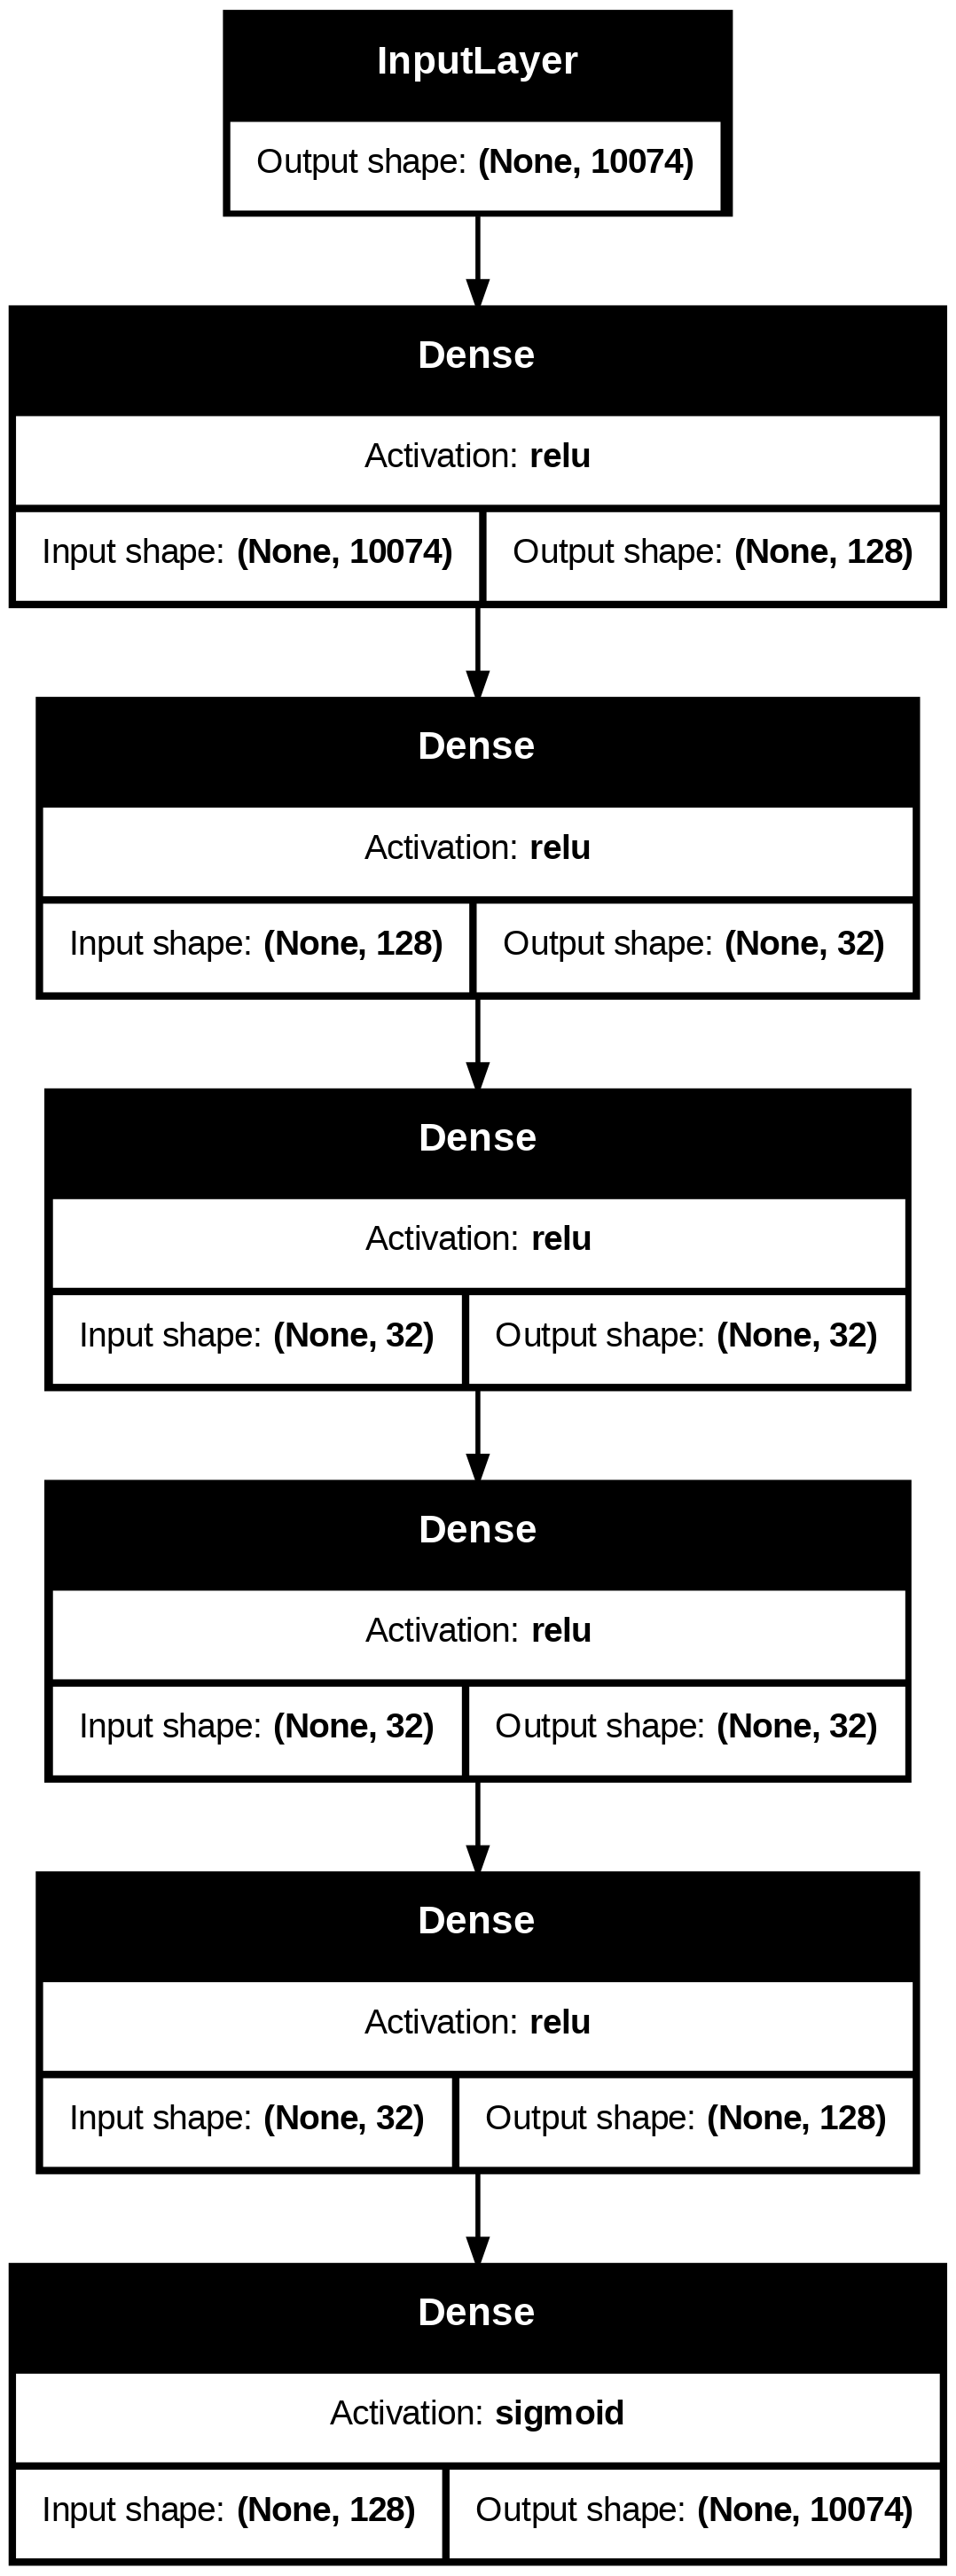

In [ ]:
from tensorflow.keras.utils import plot_model

# Loading best model
autoencoder = tuner.get_best_models(num_models=1)[0]

# Displaying a graphical representation of the best model
plot_model(autoencoder, show_shapes=True, show_layer_activations=True)

# Loading the Genre Tags Nerual Network: (Run This if Bayesian Optimization has Already Found the Best Model)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.losses import cosine_similarity

# Metric to test the accuracy of reconstructed features
def cosine_similarity_metric(y_true, y_pred):
    return tf.reduce_mean(cosine_similarity(y_true, y_pred))

def build_autoencoder_genre(input_dim=X_processed.shape[1], return_encoder=False):
    inputs = tf.keras.Input(shape=(input_dim,))

    # Encoder
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(16, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    encoder_output = layers.Dense(128, activation='relu')(x)

    # Decoder output
    outputs = layers.Dense(input_dim, activation='sigmoid')(encoder_output)

    autoencoder = Model(inputs=inputs, outputs=outputs)
    autoencoder.compile(optimizer='adam', loss='mse', metrics=[cosine_similarity_metric])

    if return_encoder:
        encoder = Model(inputs=inputs, outputs=encoder_output)
        return autoencoder, encoder
    else:
        return autoencoder

autoencoder = build_autoencoder_genre(return_encoder=False)

# Loading the Category Nerual Network: (Run This if Bayesian Optimization has Already Found the Best Model)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.losses import cosine_similarity

# Metric to test the accuracy of reconstructed features
def cosine_similarity_metric(y_true, y_pred):
    return tf.reduce_mean(cosine_similarity(y_true, y_pred))

def build_autoencoder_category(input_dim=X_processed.shape[1], return_encoder=False):
    inputs = tf.keras.Input(shape=(input_dim,))

    # Encoder
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.Dense(96, activation='relu')(x)
    x = layers.Dense(24, activation='relu')(x)
    x = layers.Dense(96, activation='relu')(x)
    encoder_output = layers.Dense(256, activation='relu')(x)

    # Decoder output
    outputs = layers.Dense(input_dim, activation='sigmoid')(encoder_output)

    autoencoder = Model(inputs=inputs, outputs=outputs)
    autoencoder.compile(optimizer='adam', loss='mse', metrics=[cosine_similarity_metric])

    if return_encoder:
        encoder = Model(inputs=inputs, outputs=encoder_output)
        return autoencoder, encoder
    else:
        return autoencoder

autoencoder = build_autoencoder_genre(return_encoder=False)

# Retraining Best model

In [ ]:
# Training best architecture
history = autoencoder.fit(X_processed, X_processed, epochs=50)

Epoch 1/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - cosine_similarity_metric: -0.9129 - loss: 4.5866e-04
Epoch 2/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - cosine_similarity_metric: -0.9143 - loss: 4.4812e-04
Epoch 3/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - cosine_similarity_metric: -0.9167 - loss: 4.2944e-04
Epoch 4/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - cosine_similarity_metric: -0.9184 - loss: 4.1758e-04
Epoch 5/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - cosine_similarity_metric: -0.9198 - loss: 4.0842e-04
Epoch 6/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - cosine_similarity_metric: -0.9211 - loss: 3.9820e-04
Epoch 7/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - cosine_similarity_metric: -0.9230 - loss: 3.8462e-04
Epoch 8/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - cosine_similarity_metric: -0.9249 - loss: 3.7000e-04
Epoch 9/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - cosine_similarity_metric: -0.9270 - loss: 3.5467e-04
Epoch 10/50
420/420

# Genre Tag Loss

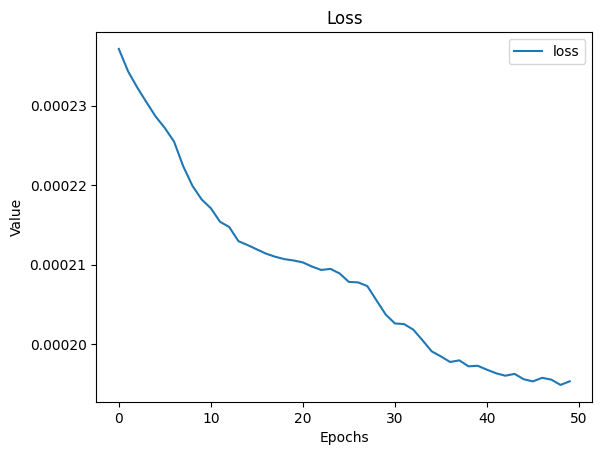

In [ ]:
# Plotting loss
plt.plot(history.history['loss'], label='loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.show()

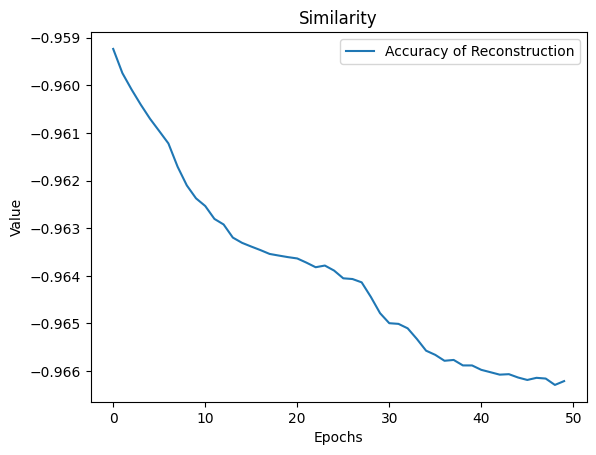

In [ ]:
# Plotting cosine_similarity_metric
plt.plot(history.history['cosine_similarity_metric'], label='Accuracy of Reconstruction')
plt.title('Similarity')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.show()

# Category Loss

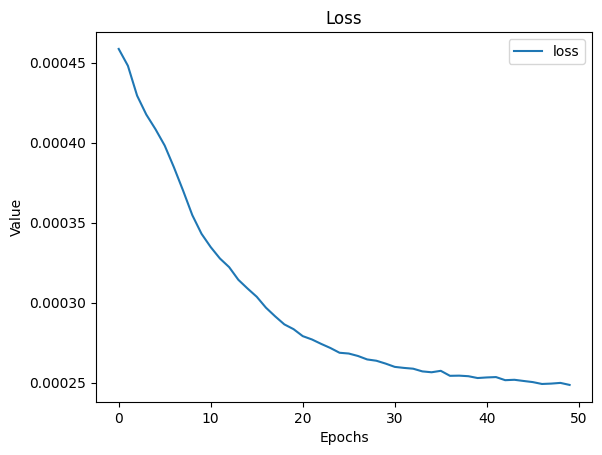

In [ ]:
# Plotting loss
plt.plot(history.history['loss'], label='loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.show()

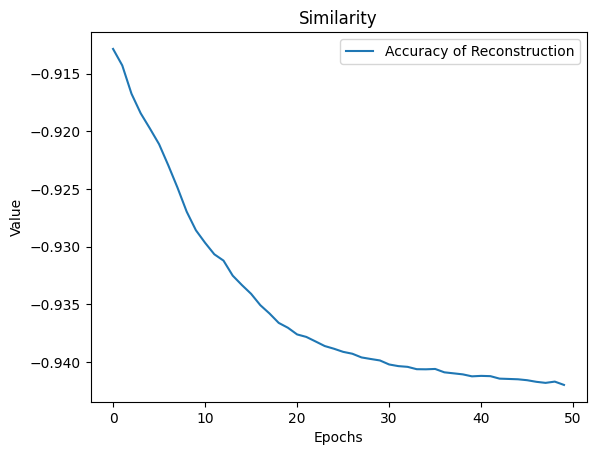

In [ ]:
# Plotting cosine_similarity_metric
plt.plot(history.history['cosine_similarity_metric'], label='Accuracy of Reconstruction')
plt.title('Similarity')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.show()

# Possible Garbage

# Using the Trained Autoencoder and Cosine Similarity Metric to Recomend Which Game Genre Tag to Attach.

In [ ]:
# Setting index of a game
game_index = 1

# Getting features of that game
game_features = X_processed[game_index]

game_features

array([0.40740741, 0.        , 0.26756219, ..., 0.        , 0.        ,
       0.        ])

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# How many games to recomend
N_games = 6

# Generating reconstruction of features using autoencoder
reconstructed_game = autoencoder.predict(np.array([game_features]))[0]

# Comparing choosen game to the rest
similarities = cosine_similarity(X_processed, [reconstructed_game])
similarities[1] = -1  # Making sure the original movie will not be recomended
most_similar_indices = np.argsort(similarities, axis=0)[::-1][:N_games]  # Getting Indexes of 10 most similar movies

most_similar_indices

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


array([[ 626],
       [ 410],
       [4034],
       [  36],
       [  25],
       [ 387]])

In [ ]:
# Printing recomended genre tags
for recomended_game in most_similar_indices:
    print(*title.values[recomended_game])

('Puzzle', 'First-Person', 'Surreal', 'Narration', 'Psychological', 'Physics', 'Singleplayer', 'Thriller', 'Story Rich', 'Adventure', 'Psychedelic', 'Funny', 'Exploration', '3D Vision', 'Puzzle-Platformer', 'Psychological Horror', 'Minimalist', 'Cinematic', 'Dark Humor', 'Colorful')
('Medieval', 'Multiplayer', 'Action', 'Gore', 'First-Person', 'Swordplay', 'Violent', 'PvP', 'Indie', 'Third Person', 'Competitive', 'Team-Based', 'Hack and Slash', 'Co-op', 'Historical', 'FPS', 'Class-Based', 'Atmospheric', 'Simulation', 'Difficult')
('Indie', 'Violent', 'Action', 'Pixel Graphics', 'Stealth', 'Strategy', 'Simulation', 'Great Soundtrack', 'Singleplayer', 'Adventure', 'Psychedelic', 'Difficult', 'Funny', 'Top-Down', 'Villain Protagonist', 'Tactical', 'Multiplayer', 'Music', 'Gore', 'Co-op')
('Zombies', 'Survival Horror', 'Horror', 'Online Co-Op', 'Open World', 'Parkour', 'First-Person', 'Survival', 'Open World Survival Craft', 'Gore', 'FPS', 'Action', 'PvE', 'Stealth', 'PvP', 'Post-apocalypt

In [ ]:
import ast

# Convert strings to tuples if necessary
ff = new_df['tags_clean'].apply(ast.literal_eval)

# Take the indices of similar games
most_sim_ind = np.argsort(similarities, axis=0)[::-1][:N_games].flatten()

top_tags = (
    ff.iloc[most_sim_ind]   # already the Series of tuples
    .apply(list)            # convert tuple -> list
    .explode()              # each tag becomes a row
    .value_counts()         # count occurrences
    .head(5)                # top 5
)

print(top_tags)

tags_clean
Open World     4
Action         4
Multiplayer    4
Adventure      3
Co-op          3
Name: count, dtype: int64


In [ ]:
import tensorflow as tf
import numpy as np

def precision_recall_at_k(y_true, y_pred, k=3):
    # Get top K indices for each sample
    top_k_values, top_k_indices = tf.nn.top_k(y_pred, k=k)

    # Gather the true labels for the top K predictions
    top_k_true = tf.gather(y_true, top_k_indices, batch_dims=1)

    # Precision@K = (# correct in top K) / K
    precision_per_sample = tf.reduce_sum(top_k_true, axis=1) / k
    precision_at_k = tf.reduce_mean(precision_per_sample).numpy()

    # Recall@K = (# correct in top K) / (# true categories)
    recall_per_sample = tf.reduce_sum(top_k_true, axis=1) / tf.maximum(1.0, tf.reduce_sum(y_true, axis=1))
    recall_at_k = tf.reduce_mean(recall_per_sample).numpy()

    return precision_at_k, recall_at_k

In [ ]:
# Get reconstructed predictions from your autoencoder
y_pred = autoencoder.predict(X_processed)
y_true = X_processed  # since this is an autoencoder

precision, recall = precision_recall_at_k(y_true, y_pred, k=33)
print(f"Precision@3: {precision:.4f}")
print(f"Recall@3: {recall:.4f}")

420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step
Precision@3: 0.8582
Recall@3: 0.8392


# Using the Trained Autoencoder and Cosine Similarity Metric to Recomend Which Game Category to Attach.

In [ ]:
# Setting index of a game
game_index = 1

# Getting features of that game
game_features = X_processed[game_index]

game_features

array([0.40740741, 0.        , 0.26756219, ..., 0.        , 0.        ,
       0.        ])

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# How many games to recomend
N_games = 5

# Generating reconstruction of features using autoencoder
reconstructed_game = autoencoder.predict(np.array([game_features]))[0]

# Comparing choosen game to the rest
similarities = cosine_similarity(X_processed, [reconstructed_game])
similarities[game_index] = -1  # Making sure the original movie will not be recomended
most_similar_indices = np.argsort(similarities, axis=0)[::-1][:N_games]  # Getting Indexes of 10 most similar movies

most_similar_indices

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step


array([[ 7291],
       [13156],
       [ 1440],
       [ 8426],
       [12637]])

In [ ]:
# Printing recomended genre tags
for recomended_game in most_similar_indices:
    print(*title.values[recomended_game])

['Single-player', 'Multi-player', 'PvP', 'Online PvP', 'Co-op', 'Online Co-op', 'Steam Achievements', 'Steam Trading Cards', 'In-App Purchases']
['Multi-player', 'MMO', 'PvP', 'Online PvP', 'Co-op', 'Online Co-op', 'Cross-Platform Multiplayer', 'Steam Achievements', 'In-App Purchases']
['Single-player', 'Steam Achievements', 'Steam Trading Cards', 'Steam Cloud', 'Remote Play on Tablet', 'Family Sharing']
['Multi-player', 'PvP', 'Online PvP', 'In-App Purchases']
['Single-player', 'Steam Achievements', 'Full controller support', 'Steam Cloud', 'Stats', 'Family Sharing']


In [ ]:
import ast

# Convert strings to tuples if necessary
ff = new_df['categories'].apply(ast.literal_eval)

# Take the indices of similar games
most_sim_ind = np.argsort(similarities, axis=0)[::-1][:N_games].flatten()

top_cats = (
    ff.iloc[most_sim_ind]   # already the Series of tuples
    .apply(list)            # convert tuple -> list
    .explode()              # each tag becomes a row
    .value_counts()         # count occurrences
    .head(5)
)
print("Top Categories Found in Relevant Games:")
print(top_cats)

Top Categories Found in Relevant Games:
categories
Family Sharing         5
Multi-player           4
Single-player          4
Co-op                  4
Steam Trading Cards    3
Name: count, dtype: int64


In [ ]:
import tensorflow as tf
import numpy as np

def precision_recall_at_k(y_true, y_pred, k=3):
    # Get top K indices for each sample
    top_k_values, top_k_indices = tf.nn.top_k(y_pred, k=k)

    # Gather the true labels for the top K predictions
    top_k_true = tf.gather(y_true, top_k_indices, batch_dims=1)

    # Precision@K = (# correct in top K) / K
    precision_per_sample = tf.reduce_sum(top_k_true, axis=1) / k
    precision_at_k = tf.reduce_mean(precision_per_sample).numpy()

    # Recall@K = (# correct in top K) / (# true categories)
    recall_per_sample = tf.reduce_sum(top_k_true, axis=1) / tf.maximum(1.0, tf.reduce_sum(y_true, axis=1))
    recall_at_k = tf.reduce_mean(recall_per_sample).numpy()

    return precision_at_k, recall_at_k

In [ ]:
# Get reconstructed predictions from your autoencoder
y_pred = autoencoder.predict(X_processed)
y_true = X_processed  # since this is an autoencoder

precision, recall = precision_recall_at_k(y_true, y_pred, k=41)
print(f"Precision@3: {precision:.4f}")
print(f"Recall@3: {recall:.4f}")

420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step
Precision@3: 0.8297
Recall@3: 0.8177


# Performance Table

In [ ]:
from IPython.display import display, HTML

html_code = """
<table border="1" cellpadding="5" cellspacing="0">
  <thead>
    <tr>
      <th>Model</th>
      <th>Best K Value</th>
      <th>Precision@K</th>
      <th>Recall@K</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Genre</td>
      <td>33</td>
      <td>85%</td>
      <td>84%</td>
    </tr>
    <tr style="border-top:2px solid black;">
      <td>Category</td>
      <td>41</td>
      <td>83%</td>
      <td>82%</td>
    </tr>
  </tbody>
</table>
"""

# Render HTML table in Colab
display(HTML(html_code))

Model,Best K Value,Precision@K,Recall@K
Genre,33,85%,84%
Category,41,83%,82%


# Performance Explanation:

Out of the two models tested, the genre tag model performed better than the category model in both precision@K and recall@k. This indicates that the genre-based recommender is more effective at returning relevant game recommendations within the top-K results.

The likely reason for this performance difference is the nature of the textual information within the short_description feature. The description in most Steam games tend to contain more information related to characteristics about a games genre rather than feature categories. As a result of this, the genre tag model  was able to extract more meaningful signals from the textual data, leading to more accurate similarity comparsions between games.

Because of this factor, the genre-tag model was able to generate more precise reccomendations, whereareas the category model required a larger number of reccomendations to achieve lower results.

# Post Mortem:
One of the major struggles I had with this project was getting accurate predictions for both models with limited space I had on Google Colab's environment. When trying to run the full dataset (+90k games) I quickly ran out of RAM due to the depth of the data contained within the dataset. The solution I used was to cut lower rated games from the dataset and prioritize the more positively rated games. This work around allowed me to train the encoder without running into over usage issues. The consequence resulted in a less accurate representation of niche genres/categories due to the lack of depth within the dataset. A different solution to this problem is to look into batching the dataset into subsets of 10,000 games each batch. This would allow my project to stay under Googles RAM limit at the cost of more training time.

Another problem occured when running the Bayesian parameter optimization. The length of time it took for the best model to be found was around an hour and twenty minutes each run. This was difficult when making adjustments to the dataset since the Bayesian optimizer needed to be run again for both models and took a great deal of my time. This is a harder problem to solve since this would require me to possibly switch to a different model or training method. The way I circumvented this issue was to save each high performing model in my own build_autoencoder function.